# TELECOM CUSTOMER CHURN PREDICTION

**Name:** Bruce Percy Jebaraj  
**Course:** DATA ANALYTICS (COMP70037)  
**Supervisor:** Dr. Rasika  
**Submission:** Report + Presentation (10th February 2026)  
**Tool:** Python (Jupyter Notebook)

---
This notebook presents and discusses the work under:

A. Introduction 
B. Data Cleaning & Preparation  
C. Data Exploration (EDA)  
D. Regression Analysis  
E. Classification Analysis  
F. Association Rule Mining  
G. Clustering Analysis  
H. Evaluation of Models  
I. Recommendations  
J. Conclusion  
K. References  
---


In [1]:
# ==============================
# 1) Imports and notebook setup
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports complete.")


✅ Imports complete.


## A. Introduction

Telecommunications companies lose significant revenue when customers discontinue their services (customer churn). Predicting churn in advance enables proactive retention actions (e.g., targeted discounts, contract upgrades, service improvements) that reduce customer loss and improve profitability.

### Business Scenario (Designed Scenario)
Assume a telecom provider runs a weekly churn-risk pipeline. The retention team receives a ranked list of customers with churn probability and recommended interventions (discounts, contract upgrades, support outreach). The business objective is to maximize retention impact by catching likely churners early.

### Objective
This notebook develops a churn prediction solution using supervised machine learning (classification). The workflow includes:
- rigorous data cleaning and preprocessing,  
- exploratory data analysis (EDA) to identify churn drivers,  
- variable selection to reduce redundancy and leakage,  
- training and evaluation of multiple classification models,  
- model comparison using business-relevant metrics (especially Recall and ROC–AUC),  
- model interpretability using feature importance and optional SHAP,  
- an interactive prediction function for business use.

### Dataset Specifications (Your dataset)
The dataset contains customer demographic, service, usage, and billing attributes, including:
- Demographics: Gender, Age, Married, Dependents  
- Behavioral/relationship: Credit Score, Referrals, Tenure  
- Service: Phone/Internet, Internet Type, Add-ons (security/backup/streaming/etc.)  
- Contract & billing: Contract, Paperless Billing, Payment Method, Monthly Charge  
- Target source: Customer Status (Stayed / Churned / Joined)

The solution is designed to be realistic and leakage-safe, providing trustworthy model performance and actionable insights.

---


## B. Data Loading and Initial Inspection

Before modeling, we load the dataset and perform an initial inspection to understand:
- number of customers and features,
- data types (numeric vs categorical),
- missing values and duplicates,
- whether the target variable exists and how it is distributed.

---


In [2]:
# ==============================
# 2) Load dataset + standardize column names
# ==============================

file_path = r"C:\Users\BrucePercy\Documents\DataAnalytics\Data Analytics - MSC25A1CS - Final Asssignment\Data Set\Telecom Customer Churn Cleaned Final Fixed.xlsx"

df_raw = pd.read_excel(file_path)
df_raw.columns = df_raw.columns.str.lower().str.strip().str.replace(" ", "_")

print("RAW shape:", df_raw.shape)
print("\nRAW columns:")
print(df_raw.columns.tolist())

print("\nRAW head:")
display(df_raw.head())


RAW shape: (7043, 39)

RAW columns:
['customer_id', 'gender', 'age', 'married', 'number_of_dependents', 'city', 'zip_code', 'latitude', 'longitude', 'credit_score', 'number_of_referrals', 'tenure_in_months', 'offer', 'phone_service', 'avg_monthly_long_distance_charges', 'multiple_lines', 'internet_service', 'internet_type', 'avg_monthly_gb_download', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'customer_status', 'churn_category', 'churn_reason']

RAW head:


,customer_id,gender,age,married,number_of_dependents,city,zip_code,latitude,longitude,credit_score,number_of_referrals,tenure_in_months,offer,phone_service,avg_monthly_long_distance_charges,multiple_lines,internet_service,internet_type,avg_monthly_gb_download,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,685,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,673,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,557,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,551,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,555,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## C. Raw Data Quality Snapshot (Before Cleaning)

We document raw data quality before transformations for transparency and reproducibility.
This supports justification for:
- missing value treatment,
- duplicate handling,
- invalid values (e.g., negative charges),
- target structure (Stayed/Churned/Joined).
---



RAW DATA QUALITY SNAPSHOT (BEFORE CLEANING)

--- 3.1 Dataset shape ---
Rows (customers): 7043
Columns (features): 39

--- 3.2 Duplicate rows ---
Duplicate row count: 0

--- 3.3 Missing values (count + %) ---


,missing_count,missing_percent
churn_category,5174,73.463013
churn_reason,5174,73.463013
offer,3877,55.047565
online_backup,1526,21.666903
premium_tech_support,1526,21.666903
avg_monthly_gb_download,1526,21.666903
online_security,1526,21.666903
streaming_movies,1526,21.666903
streaming_tv,1526,21.666903
unlimited_data,1526,21.666903


Total missing values in dataset: 30849

--- 3.4 Missing values bar chart (Top 20) ---


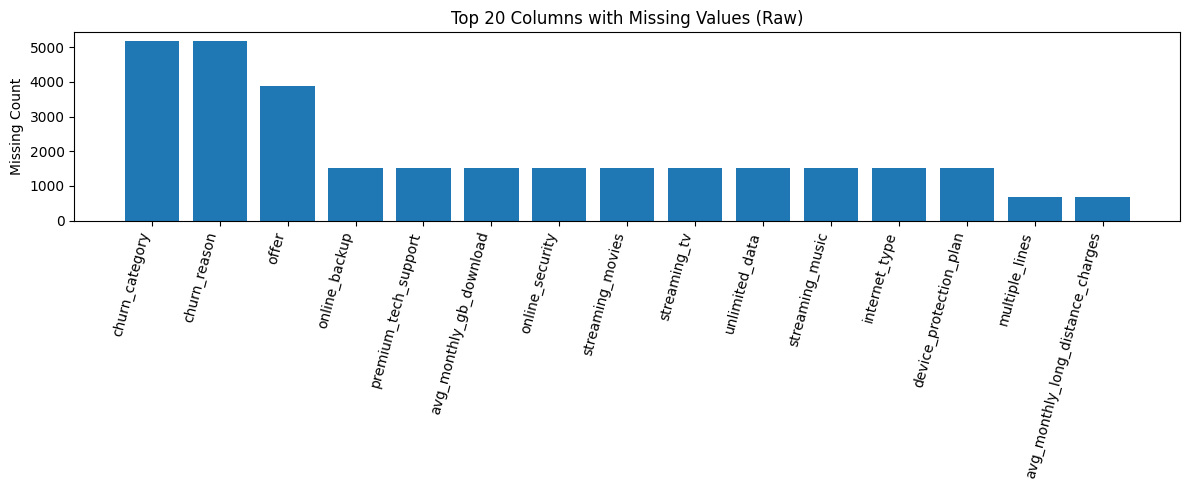


--- 3.5 Missing values heatmap (Raw) ---


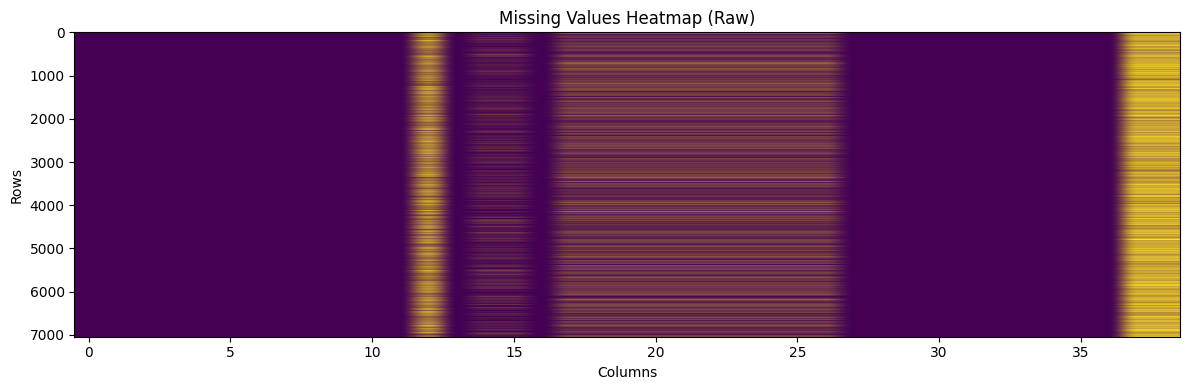


--- 3.6 customer_status distribution (Raw) ---


,count,percent
customer_status,,
Stayed,4720,67.02
Churned,1869,26.54
Joined,454,6.45


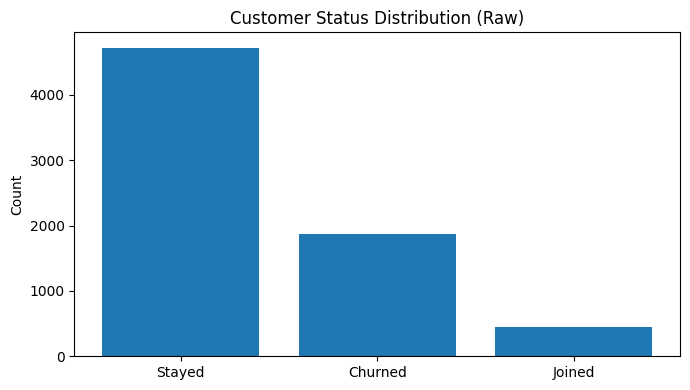


--- 3.7 Invalid values audit (negative monetary values) ---


,negative_count
monthly_charge,120



✅ Invalid-value audit complete.


In [3]:
# ==============================
# 3) Raw Data Quality Snapshot
# ==============================

print("\n" + "="*110)
print("RAW DATA QUALITY SNAPSHOT (BEFORE CLEANING)")
print("="*110)

# 3.1 Dataset shape
print("\n--- 3.1 Dataset shape ---")
print("Rows (customers):", df_raw.shape[0])
print("Columns (features):", df_raw.shape[1])

# 3.2 Duplicate rows
print("\n--- 3.2 Duplicate rows ---")
dup_count = df_raw.duplicated().sum()
print("Duplicate row count:", dup_count)

# 3.3 Missing values table
print("\n--- 3.3 Missing values (count + %) ---")
missing_count = df_raw.isnull().sum()
missing_percent = (missing_count / len(df_raw)) * 100

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)

missing_table_nonzero = missing_table[missing_table["missing_count"] > 0]
display(missing_table_nonzero.head(25))
print("Total missing values in dataset:", int(df_raw.isnull().sum().sum()))

# 3.4 Missing values bar chart (Top 20)
print("\n--- 3.4 Missing values bar chart (Top 20) ---")
top_missing = missing_table_nonzero.head(20)

if len(top_missing) > 0:
    plt.figure(figsize=(12, 5))
    plt.bar(top_missing.index.astype(str), top_missing["missing_count"].values)
    plt.title("Top 20 Columns with Missing Values (Raw)")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in raw dataset.")

# 3.5 Missing values heatmap (raw)
print("\n--- 3.5 Missing values heatmap (Raw) ---")
plt.figure(figsize=(12, 4))
plt.imshow(df_raw.isnull(), aspect="auto")
plt.title("Missing Values Heatmap (Raw)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

# 3.6 Target distribution in raw data
print("\n--- 3.6 customer_status distribution (Raw) ---")
if "customer_status" in df_raw.columns:
    status_counts = df_raw["customer_status"].value_counts(dropna=False)
    status_percent = df_raw["customer_status"].value_counts(normalize=True, dropna=False) * 100
    display(pd.DataFrame({"count": status_counts, "percent": status_percent.round(2)}))

    plt.figure(figsize=(7, 4))
    plt.bar(status_counts.index.astype(str), status_counts.values)
    plt.title("Customer Status Distribution (Raw)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("customer_status not found. Check dataset columns.")

# 3.7 Invalid values audit (negative monetary values)
print("\n--- 3.7 Invalid values audit (negative monetary values) ---")
money_cols = [
    "monthly_charge",
    "avg_monthly_long_distance_charges",
    "total_charges",
    "total_refunds",
    "total_extra_data_charges",
    "total_long_distance_charges",
    "total_revenue"
]

invalid_report = {}
for c in money_cols:
    if c in df_raw.columns:
        invalid_report[c] = int((pd.to_numeric(df_raw[c], errors="coerce") < 0).sum())

# ✅ Correct construction (no transpose issues)
invalid_df = (
    pd.Series(invalid_report, name="negative_count")
      .to_frame()
      .sort_values("negative_count", ascending=False)
)

display(invalid_df[invalid_df["negative_count"] > 0])

print("\n✅ Invalid-value audit complete.")


## B. Data Cleaning and Preparation (Performed Before EDA)

Cleaning is performed before EDA so that patterns observed in analysis are not distorted by missingness artifacts, invalid values, or leakage variables.

### Key decisions (business and analytical justification)

1. **Remove Joined customers**: They have not been in service long enough for churn to be meaningfully observed.  
2. **Create a binary churn target**: Keep `churn` (0/1) for classification.  
3. **Remove leakage variables**: Churn reasons/categories and cumulative totals may encode churn after the fact.  
4. **Missing values handling before EDA**: Apply service dependency rules + robust imputation.  
5. **Remove identifiers**: Unique IDs and raw location fields do not generalize.

---


In [4]:
# ==============================
# 4) Cleaning & Preprocessing
# ==============================

df = df_raw.copy()

# 4.1 Remove Joined + create target churn
df = df[df["customer_status"].isin(["Stayed", "Churned"])].copy()
df["churn"] = (df["customer_status"] == "Churned").astype(int)
df.drop(columns=["customer_status"], inplace=True)

print("After removing Joined + creating churn target:")
print("Shape:", df.shape)
print(df["churn"].value_counts())
print("Churn rate (%):", round(df["churn"].mean() * 100, 2))

# 4.2 Remove leakage variables
leakage_cols = [
    "churn_category",
    "churn_reason",
    "total_revenue",
    "total_charges",
    "total_long_distance_charges",
    "total_refunds",
    "total_extra_data_charges"
]
existing_leakage = [c for c in leakage_cols if c in df.columns]
df.drop(columns=existing_leakage, inplace=True)

print("\nDropped leakage columns:", existing_leakage)
print("Shape after leakage removal:", df.shape)

# 4.3 Standardize hidden missing values (blanks -> NaN)
obj_cols = df.select_dtypes(include="object").columns
for c in obj_cols:
    df[c] = df[c].replace(r"^\s*$", np.nan, regex=True)

print("\nMissing values after standardization:", int(df.isnull().sum().sum()))

# 4.4 Business-rule handling for service-dependent variables
internet_addons = [
    "online_security","online_backup","device_protection_plan","premium_tech_support",
    "streaming_tv","streaming_movies","streaming_music","unlimited_data"
]

# Internet rules
if "internet_service" in df.columns:
    no_internet = df["internet_service"] == "No"

    if "internet_type" in df.columns:
        df.loc[no_internet, "internet_type"] = "No Internet"
    if "avg_monthly_gb_download" in df.columns:
        df.loc[no_internet, "avg_monthly_gb_download"] = 0

    for c in internet_addons:
        if c in df.columns:
            df.loc[no_internet, c] = "No"

# Phone rules
if "phone_service" in df.columns:
    no_phone = df["phone_service"] == "No"

    if "avg_monthly_long_distance_charges" in df.columns:
        df.loc[no_phone, "avg_monthly_long_distance_charges"] = 0
    if "multiple_lines" in df.columns:
        df.loc[no_phone, "multiple_lines"] = "No"

print("Missing values after business rules:", int(df.isnull().sum().sum()))

# 4.5 Fix invalid numeric values (negative charges -> NaN)
numeric_check_cols = ["monthly_charge", "avg_monthly_long_distance_charges", "avg_monthly_gb_download"]
for c in numeric_check_cols:
    if c in df.columns:
        df.loc[df[c] < 0, c] = np.nan

print("Missing values after invalid-value fixes:", int(df.isnull().sum().sum()))

# 4.6 Final imputation: median for numeric, mode for categorical
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("\n✅ Final missing values:", int(df.isnull().sum().sum()))

# 4.7 Remove identifiers and address/location-related variables
drop_non_predictive = [
    "customer_id",
    "city",
    "zip_code",
    "latitude",
    "longitude"
]
existing = [c for c in drop_non_predictive if c in df.columns]
df.drop(columns=existing, inplace=True)

print("Dropped non-predictive/address columns:", existing)
print("Final cleaned shape:", df.shape)

display(df.head())


After removing Joined + creating churn target:
Shape: (6589, 39)
churn
0    4720
1    1869
Name: count, dtype: int64
Churn rate (%): 28.37

Dropped leakage columns: ['churn_category', 'churn_reason', 'total_revenue', 'total_charges', 'total_long_distance_charges', 'total_refunds', 'total_extra_data_charges']
Shape after leakage removal: (6589, 32)

Missing values after standardization: 18326
Missing values after business rules: 3598
Missing values after invalid-value fixes: 3712

✅ Final missing values: 0
Dropped non-predictive/address columns: ['customer_id', 'city', 'zip_code', 'latitude', 'longitude']
Final cleaned shape: (6589, 27)


,gender,age,married,number_of_dependents,credit_score,number_of_referrals,tenure_in_months,offer,phone_service,avg_monthly_long_distance_charges,multiple_lines,internet_service,internet_type,avg_monthly_gb_download,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,monthly_charge,churn
0,Female,37,Yes,0,685,2,9,Offer B,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,0
1,Male,46,No,0,673,0,9,Offer B,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,72.9,0
2,Male,50,No,0,557,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,1
3,Male,78,Yes,0,551,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1
4,Female,75,Yes,0,555,3,3,Offer B,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,1


## 5. Feature Selection and Variable Reduction

Feature selection is included to justify how variables were reduced and to improve:
- interpretability,
- redundancy reduction (multicollinearity),
- generalization,
- leakage prevention.

This notebook applies:
1) Correlation with churn (numeric),
2) Multicollinearity reduction (>|0.90|),
3) Random Forest feature importance (model-based).
---


In [5]:
# ==============================
# 5) Feature Selection
# ==============================

print("\n" + "="*110)
print("FEATURE SELECTION")
print("="*110)

# 5.1 Correlation with churn (numeric)
numeric_features = df.select_dtypes(include=["int64", "float64"]).drop(columns=["churn"]).columns.tolist()

if len(numeric_features) > 0:
    corr_with_target = df[numeric_features + ["churn"]].corr(numeric_only=True)["churn"].sort_values(ascending=False)
    print("\nCorrelation with churn (numeric features):")
    display(corr_with_target)
else:
    print("No numeric features found for correlation analysis.")

# 5.2 Multicollinearity reduction among numeric features
if len(numeric_features) > 1:
    corr_matrix = df[numeric_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.90)]
else:
    to_drop_corr = []

print("\nHighly correlated numeric features to drop (>|0.90|):", to_drop_corr)
df.drop(columns=to_drop_corr, inplace=True)

print("Shape after multicollinearity drop:", df.shape)

# 5.3 Model-based feature importance (Random Forest)
X_fs = df.drop(columns=["churn"])
y_fs = df["churn"]

num_cols_fs = X_fs.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_fs = X_fs.select_dtypes(include=["object"]).columns.tolist()

preprocess_fs = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_fs),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))]), cat_cols_fs)
    ],
    remainder="drop"
)

rf_fs = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

fs_pipe = Pipeline([("prep", preprocess_fs), ("rf", rf_fs)])
fs_pipe.fit(X_fs, y_fs)

# Extract feature names after OHE
if len(cat_cols_fs) > 0:
    ohe = fs_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
    ohe_names = ohe.get_feature_names_out(cat_cols_fs)
else:
    ohe_names = np.array([])

feature_names = np.r_[num_cols_fs, ohe_names]
importances = fs_pipe.named_steps["rf"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

print("\nTop 25 features by Random Forest importance:")
display(imp_df.head(25))



FEATURE SELECTION

Correlation with churn (numeric features):


churn                                1.000000
monthly_charge                       0.174107
age                                  0.111174
avg_monthly_gb_download              0.040061
avg_monthly_long_distance_charges    0.006647
number_of_dependents                -0.232525
number_of_referrals                 -0.312118
tenure_in_months                    -0.433759
credit_score                        -0.702225
Name: churn, dtype: float64


Highly correlated numeric features to drop (>|0.90|): []
Shape after multicollinearity drop: (6589, 27)

Top 25 features by Random Forest importance:


,feature,importance
2,credit_score,0.474935
4,tenure_in_months,0.127205
3,number_of_referrals,0.069712
29,contract_Two Year,0.063877
7,monthly_charge,0.030752
1,number_of_dependents,0.029097
18,internet_type_Fiber Optic,0.026681
28,contract_One Year,0.024858
6,avg_monthly_gb_download,0.021108
13,offer_Offer E,0.015039


## C. Data Exploration (EDA) on the Cleaned Dataset

EDA is performed after cleaning to ensure that results reflect real patterns rather than missingness artifacts or invalid values.

Main goals:
- confirm class imbalance,
- understand distributions of key churn drivers,
- understand relationships between features and churn,
- provide business interpretation.

### Credit Score Interpretation (business context)
A typical credit scoring range is 300–850:
- 300–579: Poor  
- 580–669: Fair  
- 670–739: Good  
- 740–799: Very Good  
- 800–850: Excellent  
---



EDA (AFTER CLEANING)

--- Descriptive statistics (numeric) ---


,age,number_of_dependents,credit_score,number_of_referrals,tenure_in_months,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,churn
count,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000
mean,46.760510,0.476097,605.889209,2.020944,34.499772,23.004277,20.876461,66.386682,0.283655
std,16.841362,0.968499,80.583291,3.024016,23.968734,15.466844,20.406247,29.670341,0.450805
min,19.000000,0.000000,345.000000,0.000000,1.000000,0.000000,0.000000,18.250000,0.000000
25%,33.000000,0.000000,560.000000,0.000000,12.000000,9.250000,4.000000,43.300000,0.000000
50%,46.000000,0.000000,607.000000,0.000000,32.000000,22.920000,17.000000,72.900000,0.000000
75%,60.000000,0.000000,668.000000,3.000000,57.000000,36.440000,27.000000,90.400000,1.000000
max,80.000000,9.000000,876.000000,11.000000,72.000000,49.990000,85.000000,118.750000,1.000000



--- Class imbalance ---
Class counts:
 churn
0    4720
1    1869
Name: count, dtype: int64
Churn rate: 28.37%


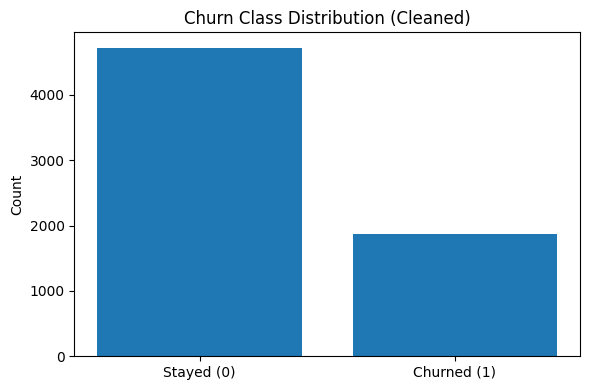

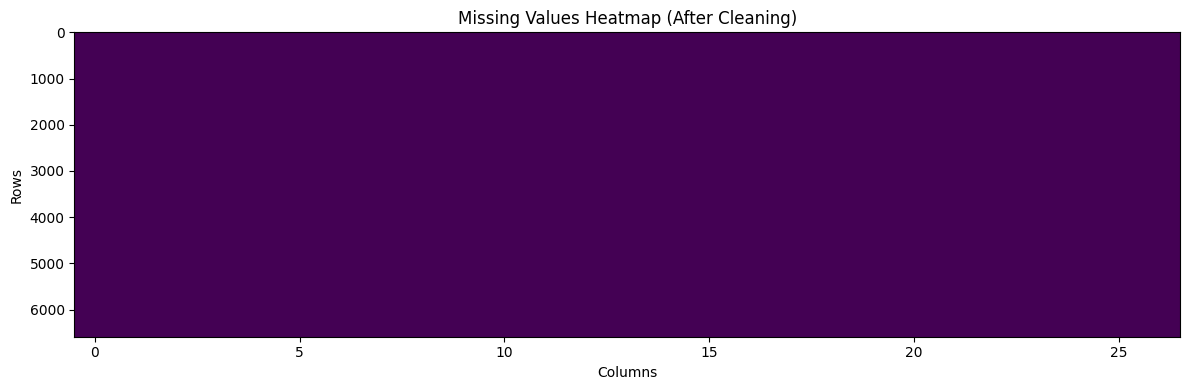

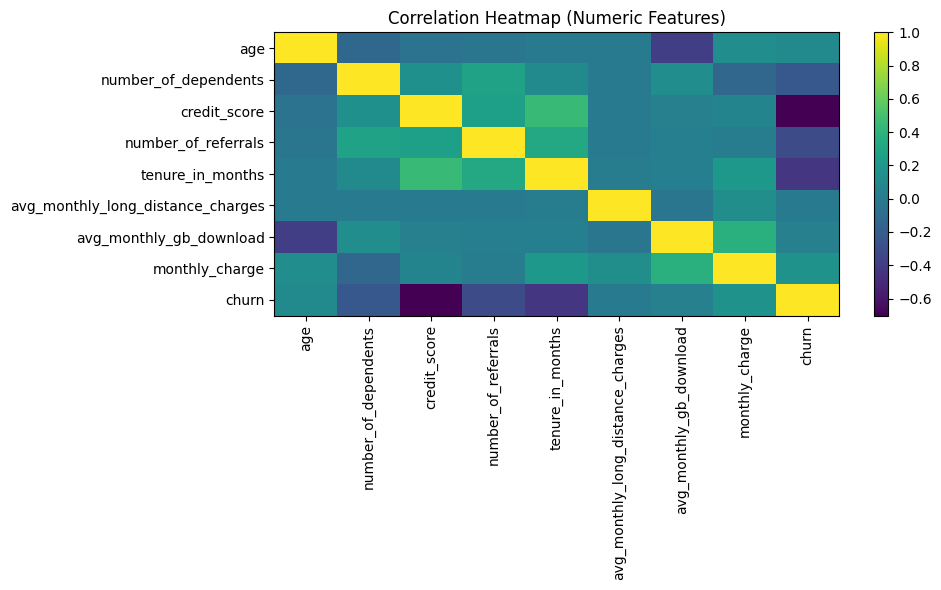

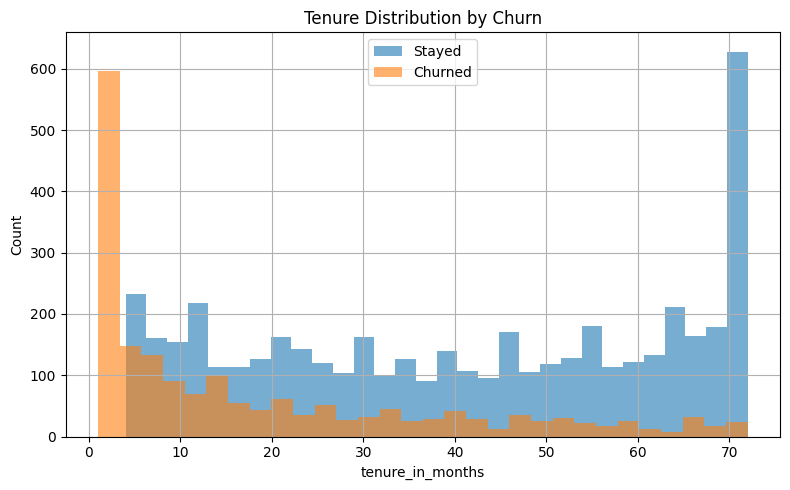

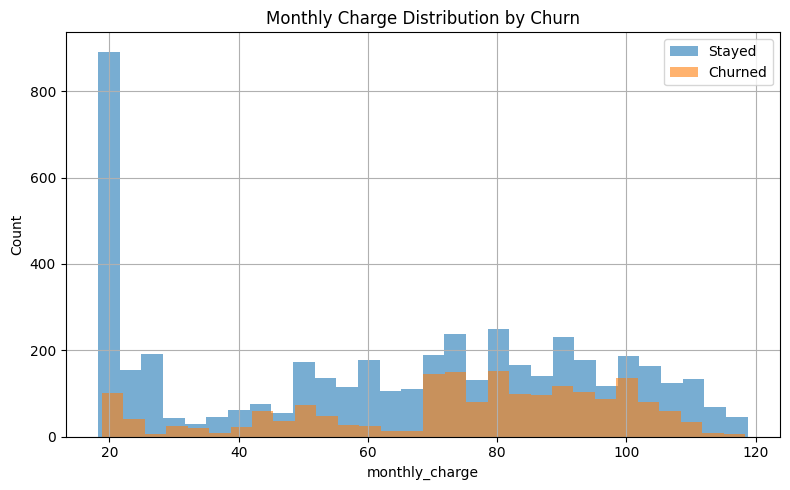

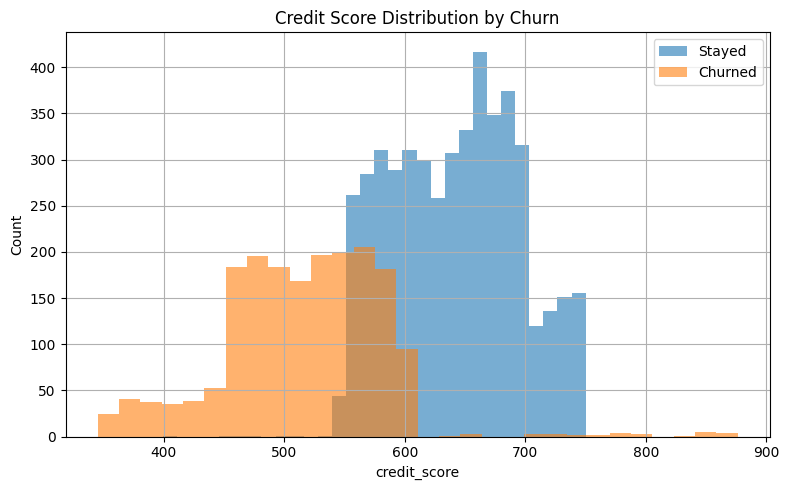

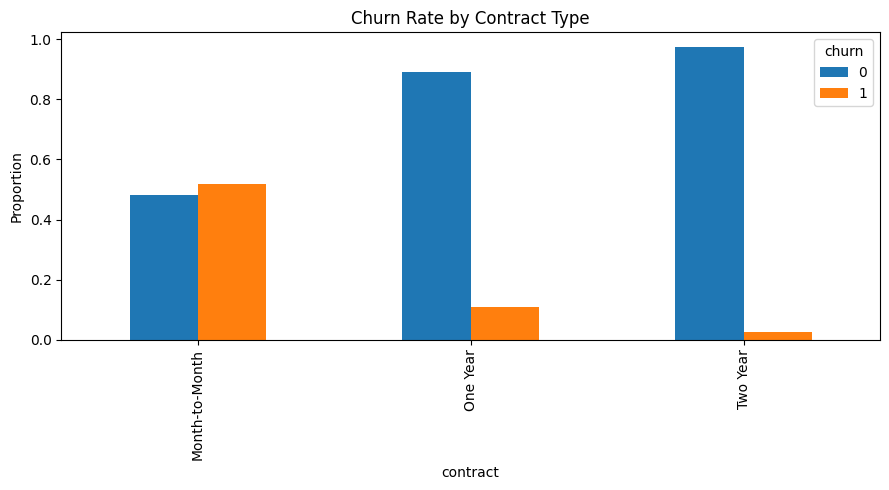

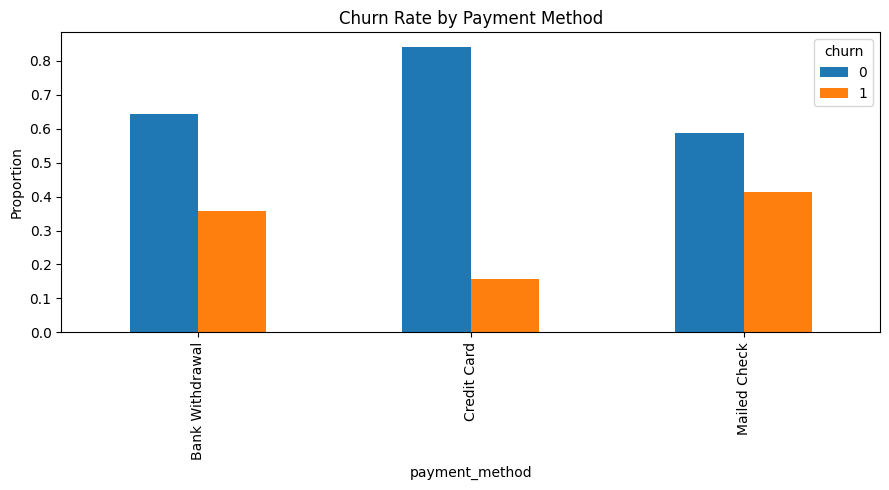

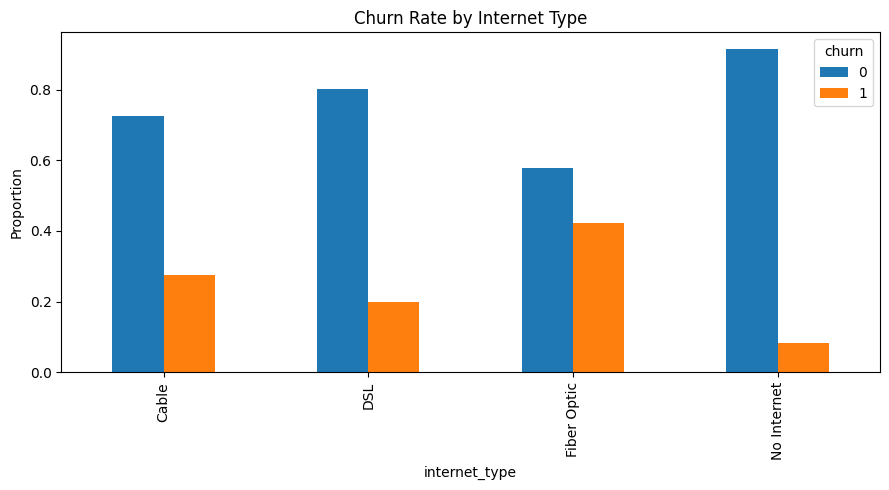

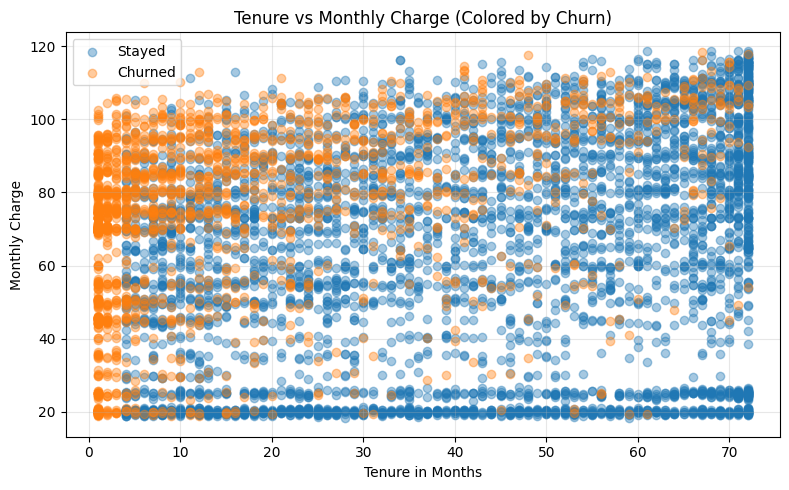

C:\Users\BrucePercy\AppData\Local\Temp\ipykernel_800\3511850886.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c].values for c in box_cols], labels=box_cols)


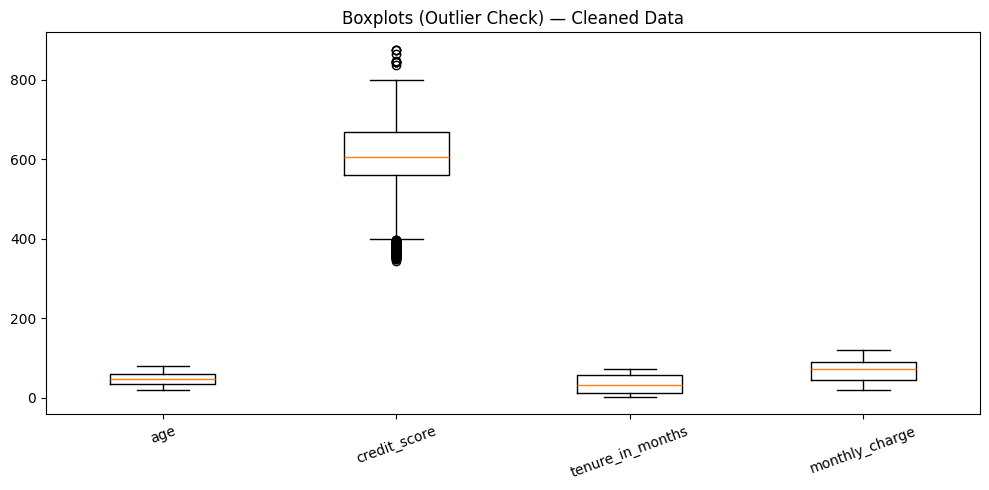

In [6]:
# ==============================
# 6) EDA (After Cleaning)
# ==============================

print("\n" + "="*110)
print("EDA (AFTER CLEANING)")
print("="*110)

# 6.1 Descriptive statistics
print("\n--- Descriptive statistics (numeric) ---")
display(df.describe())

# 6.2 Class imbalance analysis
print("\n--- Class imbalance ---")
counts = df["churn"].value_counts()
rate = df["churn"].mean() * 100
print("Class counts:\n", counts)
print(f"Churn rate: {rate:.2f}%")

plt.figure(figsize=(6, 4))
plt.bar(["Stayed (0)", "Churned (1)"], counts.values)
plt.title("Churn Class Distribution (Cleaned)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 6.3 Missing values heatmap (after cleaning)
plt.figure(figsize=(12, 4))
plt.imshow(df.isnull(), aspect="auto")
plt.title("Missing Values Heatmap (After Cleaning)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

# 6.4 Correlation heatmap (numeric)
numeric_cols_eda = df.select_dtypes(include=["int64", "float64"]).columns
corr = df[numeric_cols_eda].corr(numeric_only=True)

plt.figure(figsize=(10, 6))
plt.imshow(corr, aspect="auto")
plt.title("Correlation Heatmap (Numeric Features)")
plt.colorbar()
plt.xticks(range(len(numeric_cols_eda)), numeric_cols_eda, rotation=90)
plt.yticks(range(len(numeric_cols_eda)), numeric_cols_eda)
plt.tight_layout()
plt.show()

# 6.5 Key drivers: tenure, monthly charge, credit score (by churn)
def hist_by_churn(col, bins=30, title=None):
    if col not in df.columns:
        return
    plt.figure(figsize=(8, 5))
    df[df["churn"] == 0][col].hist(bins=bins, alpha=0.6, label="Stayed")
    df[df["churn"] == 1][col].hist(bins=bins, alpha=0.6, label="Churned")
    plt.title(title if title else f"{col} Distribution by Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

hist_by_churn("tenure_in_months", title="Tenure Distribution by Churn")
hist_by_churn("monthly_charge", title="Monthly Charge Distribution by Churn")
hist_by_churn("credit_score", title="Credit Score Distribution by Churn")

# 6.6 Categorical churn rates (contract, payment method, internet type)
def churn_rate_bar(feature, title=None):
    if feature not in df.columns:
        return
    tab = pd.crosstab(df[feature], df["churn"], normalize="index")
    ax = tab.plot(kind="bar", figsize=(9, 5))
    plt.title(title if title else f"Churn Rate by {feature}")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()

churn_rate_bar("contract", "Churn Rate by Contract Type")
churn_rate_bar("payment_method", "Churn Rate by Payment Method")
churn_rate_bar("internet_type", "Churn Rate by Internet Type")

# 6.7 Tenure vs Monthly Charge (scatter) colored by churn
if "tenure_in_months" in df.columns and "monthly_charge" in df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[df["churn"] == 0]["tenure_in_months"], df[df["churn"] == 0]["monthly_charge"], alpha=0.4, label="Stayed")
    plt.scatter(df[df["churn"] == 1]["tenure_in_months"], df[df["churn"] == 1]["monthly_charge"], alpha=0.4, label="Churned")
    plt.title("Tenure vs Monthly Charge (Colored by Churn)")
    plt.xlabel("Tenure in Months")
    plt.ylabel("Monthly Charge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6.8 Outlier check (boxplots) for key numeric fields
box_cols = [c for c in ["age", "credit_score", "tenure_in_months", "monthly_charge"] if c in df.columns]
if len(box_cols) > 0:
    plt.figure(figsize=(10, 5))
    plt.boxplot([df[c].values for c in box_cols], labels=box_cols)
    plt.title("Boxplots (Outlier Check) — Cleaned Data")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## D. Regression Analysis 

Regression predicts a **continuous numeric outcome**. 

### Designed Regression Scenario
A telecom provider wants to **estimate Monthly Charge** based on customer profile and service configuration.  
This supports pricing analysis and helps understand what factors drive higher charges.

**Regression Target:** `monthly_charge` (continuous)

We train:
- Linear Regression (baseline)
- Random Forest Regressor (non-linear)

We evaluate:
- MAE (average absolute error)
- RMSE (error magnitude)
- R² (variance explained)
---


In [7]:
# ==============================
# D) REGRESSION ANALYSIS (NEW)
# Target: monthly_charge
# ==============================

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_reg = df.copy()

reg_target = "monthly_charge"
Xr = df_reg.drop(columns=[reg_target, "churn"])
yr = df_reg[reg_target]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.20, random_state=42
)

num_cols_r = Xr_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_r = Xr_train.select_dtypes(include=["object"]).columns.tolist()

preprocess_r = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols_r),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))]), cat_cols_r)
    ],
    remainder="drop"
)

reg_models = {
    "Linear Regression": Pipeline([("prep", preprocess_r),
                                   ("model", LinearRegression())]),
    "Random Forest Regressor": Pipeline([("prep", preprocess_r),
                                         ("model", RandomForestRegressor(
                                             n_estimators=300, random_state=42, n_jobs=-1
                                         ))])
}

reg_results = []
for name, pipe in reg_models.items():
    pipe.fit(Xr_train, yr_train)
    preds = pipe.predict(Xr_test)

    mae = mean_absolute_error(yr_test, preds)
    rmse = np.sqrt(mean_squared_error(yr_test, preds))  # ✅ compatible fix
    r2 = r2_score(yr_test, preds)

    reg_results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

reg_comparison = pd.DataFrame(reg_results).sort_values("R2", ascending=False)
display(reg_comparison)



,Model,MAE,RMSE,R2
0,Linear Regression,1.856423,5.419198,0.965721
1,Random Forest Regressor,2.282492,5.856293,0.959968


## E. Classification Analysis 

This business problem is a **classification problem**: predict whether a customer will churn (1) or stay (0).

To satisfy the requirement of comparing multiple approaches, we train:
1. Logistic Regression (baseline, interpretable)
2. Random Forest (non-linear, interactions)
3. Gradient Boosting (strong tabular performance)
4. SVM (RBF) (margin-based, non-linear)

### Imbalance Handling
Churn is often imbalanced, so we apply **class_weight="balanced"** for models that support it.
---


In [8]:
# ==============================
# 7) Train-test split + preprocessing pipelines
# ==============================

print("\n" + "="*110)
print("MODEL BUILDING")
print("="*110)

X = df.drop(columns=["churn"])
y = df["churn"]

# Stratified split keeps churn rate consistent between train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4), "| Test churn rate:", round(y_test.mean(), 4))

# Identify numeric and categorical columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# Pipelines (scaled for LR & SVM; no-scale for tree models)
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))]), cat_cols)
    ],
    remainder="drop"
)

preprocess_noscale = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))]), cat_cols)
    ],
    remainder="drop"
)

# Define models
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocess_scaled),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess_noscale),
        ("model", RandomForestClassifier(
            n_estimators=300, max_depth=10, min_samples_split=10, min_samples_leaf=5,
            class_weight="balanced", random_state=42, n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocess_noscale),
        ("model", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42))
    ]),
    "SVM (RBF)": Pipeline([
        ("prep", preprocess_scaled),
        ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ])
}

print("✅ Models defined:", list(models.keys()))



MODEL BUILDING
Train shape: (5271, 26) | Test shape: (1318, 26)
Train churn rate: 0.2836 | Test churn rate: 0.2838
✅ Models defined: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM (RBF)']


## H. Model Evaluation (Classification Metrics + Overfitting Checks)

We evaluate with:
- Accuracy
- Precision/Recall/F1 for churn class (1)
- ROC–AUC
- Confusion matrix
- ROC curve
- Train vs Test AUC gap (overfitting indicator)
---



MODEL: Logistic Regression
Accuracy:  0.9294
Precision: 0.8306  (Churn=1)
Recall:    0.9439  (Churn=1)
F1-score:  0.8836  (Churn=1)
Train AUC: 0.9764
Test AUC:  0.9804
AUC Gap (Train-Test): -0.0040

Confusion Matrix:
[[872  72]
 [ 21 353]]

Classification Report (Test):
              precision    recall  f1-score   support

  Stayed (0)       0.98      0.92      0.95       944
 Churned (1)       0.83      0.94      0.88       374

    accuracy                           0.93      1318
   macro avg       0.90      0.93      0.92      1318
weighted avg       0.94      0.93      0.93      1318



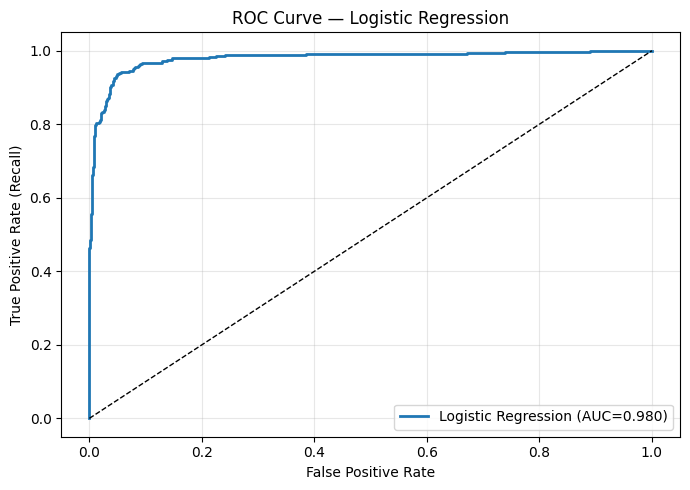


MODEL: Random Forest
Accuracy:  0.9560
Precision: 0.8930  (Churn=1)
Recall:    0.9599  (Churn=1)
F1-score:  0.9253  (Churn=1)
Train AUC: 0.9959
Test AUC:  0.9906
AUC Gap (Train-Test): 0.0053

Confusion Matrix:
[[901  43]
 [ 15 359]]

Classification Report (Test):
              precision    recall  f1-score   support

  Stayed (0)       0.98      0.95      0.97       944
 Churned (1)       0.89      0.96      0.93       374

    accuracy                           0.96      1318
   macro avg       0.94      0.96      0.95      1318
weighted avg       0.96      0.96      0.96      1318



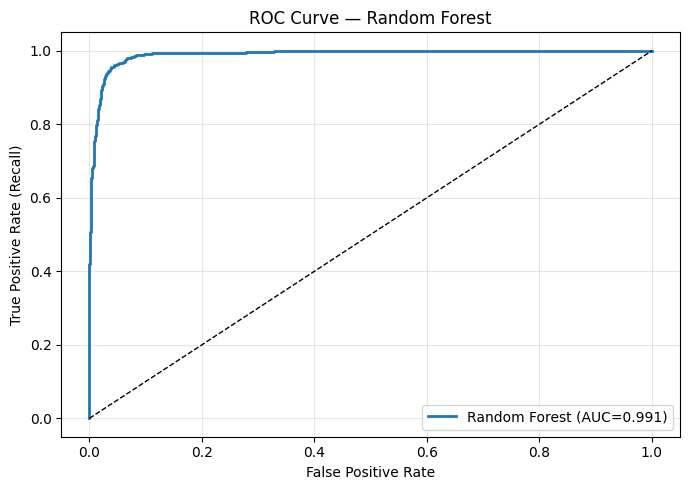


MODEL: Gradient Boosting
Accuracy:  0.9605
Precision: 0.9448  (Churn=1)
Recall:    0.9144  (Churn=1)
F1-score:  0.9293  (Churn=1)
Train AUC: 0.9967
Test AUC:  0.9940
AUC Gap (Train-Test): 0.0026

Confusion Matrix:
[[924  20]
 [ 32 342]]

Classification Report (Test):
              precision    recall  f1-score   support

  Stayed (0)       0.97      0.98      0.97       944
 Churned (1)       0.94      0.91      0.93       374

    accuracy                           0.96      1318
   macro avg       0.96      0.95      0.95      1318
weighted avg       0.96      0.96      0.96      1318



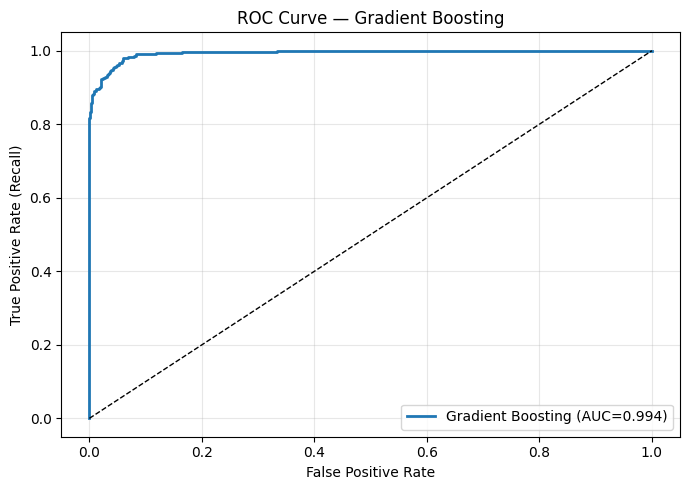


MODEL: SVM (RBF)
Accuracy:  0.9499
Precision: 0.9208  (Churn=1)
Recall:    0.9011  (Churn=1)
F1-score:  0.9108  (Churn=1)
Train AUC: 0.9915
Test AUC:  0.9881
AUC Gap (Train-Test): 0.0033

Confusion Matrix:
[[915  29]
 [ 37 337]]

Classification Report (Test):
              precision    recall  f1-score   support

  Stayed (0)       0.96      0.97      0.97       944
 Churned (1)       0.92      0.90      0.91       374

    accuracy                           0.95      1318
   macro avg       0.94      0.94      0.94      1318
weighted avg       0.95      0.95      0.95      1318



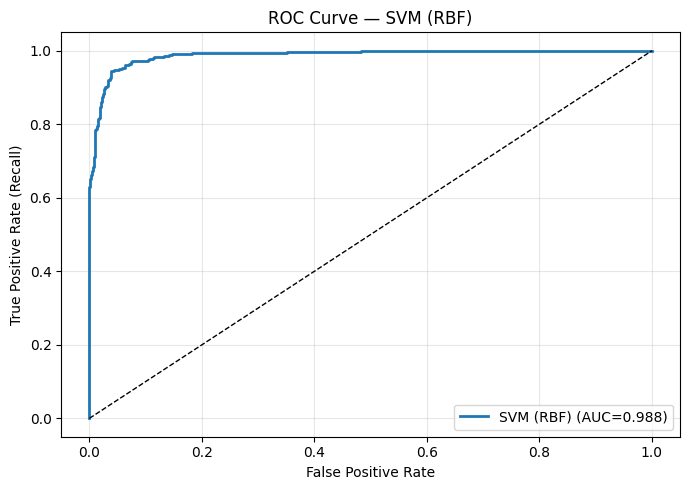


MODEL COMPARISON TABLE (SORTED BY TEST AUC)


,Model,Test Accuracy,Precision (Churn=1),Recall (Churn=1),F1 (Churn=1),Train AUC,Test AUC,AUC Gap (Overfit)
2,Gradient Boosting,0.960546,0.944751,0.914439,0.929348,0.996664,0.994024,0.002641
1,Random Forest,0.955994,0.893035,0.959893,0.925258,0.995907,0.990585,0.005322
3,SVM (RBF),0.949924,0.920765,0.901070,0.910811,0.991470,0.988146,0.003323
0,Logistic Regression,0.929439,0.830588,0.943850,0.883605,0.976396,0.980445,-0.004049


In [9]:
# ==============================
# 8) Evaluation function + train models
# ==============================

def evaluate_model(name, pipe, X_train, y_train, X_test, y_test, threshold=0.5):
    pipe.fit(X_train, y_train)

    train_proba = pipe.predict_proba(X_train)[:, 1]
    test_proba  = pipe.predict_proba(X_test)[:, 1]

    test_pred = (test_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred, zero_division=0)
    rec = recall_score(y_test, test_pred, zero_division=0)
    f1 = f1_score(y_test, test_pred, zero_division=0)

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc  = roc_auc_score(y_test, test_proba)
    gap = train_auc - test_auc

    cm = confusion_matrix(y_test, test_pred)

    print("\n" + "="*95)
    print(f"MODEL: {name}")
    print("="*95)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}  (Churn=1)")
    print(f"Recall:    {rec:.4f}  (Churn=1)")
    print(f"F1-score:  {f1:.4f}  (Churn=1)")
    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test AUC:  {test_auc:.4f}")
    print(f"AUC Gap (Train-Test): {gap:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report (Test):")
    print(classification_report(y_test, test_pred, target_names=["Stayed (0)", "Churned (1)"]))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, test_proba)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={test_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.title(f"ROC Curve — {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Test Accuracy": acc,
        "Precision (Churn=1)": prec,
        "Recall (Churn=1)": rec,
        "F1 (Churn=1)": f1,
        "Train AUC": train_auc,
        "Test AUC": test_auc,
        "AUC Gap (Overfit)": gap
    }

results = []
for name, pipe in models.items():
    results.append(evaluate_model(name, pipe, X_train, y_train, X_test, y_test))

comparison = pd.DataFrame(results).sort_values("Test AUC", ascending=False)

print("\n" + "="*110)
print("MODEL COMPARISON TABLE (SORTED BY TEST AUC)")
print("="*110)
display(comparison)


## 9. Cross-Validation (Generalization Evidence)

A single train-test split can vary due to randomness.
We apply **5-fold Stratified CV** using ROC–AUC on the best model by Test AUC.
---


In [10]:
# ==============================
# 9) Cross-validation (5-fold ROC-AUC)
# ==============================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model_name = comparison.iloc[0]["Model"]
best_pipe = models[best_model_name]

cv_auc = cross_val_score(best_pipe, X, y, cv=cv, scoring="roc_auc")

print("\n" + "="*95)
print("CROSS-VALIDATION RESULTS")
print("="*95)
print("Best model (by test AUC):", best_model_name)
print("5-fold CV AUC scores:", np.round(cv_auc, 4))
print("Mean CV AUC:", round(cv_auc.mean(), 4), "Std:", round(cv_auc.std(), 4))



CROSS-VALIDATION RESULTS
Best model (by test AUC): Gradient Boosting
5-fold CV AUC scores: [0.9922 0.9952 0.9908 0.9927 0.9946]
Mean CV AUC: 0.9931 Std: 0.0016


## 10. Model Interpretability (Feature Importance)

Interpretability supports business trust and decision-making.
Tree-based models can provide feature importance to highlight dominant churn drivers.
---



Top 20 features (Random Forest importance):


,feature,importance
2,credit_score,0.456786
4,tenure_in_months,0.131081
3,number_of_referrals,0.070462
29,contract_Two Year,0.064369
1,number_of_dependents,0.031927
7,monthly_charge,0.031904
18,internet_type_Fiber Optic,0.028318
6,avg_monthly_gb_download,0.023865
28,contract_One Year,0.022958
13,offer_Offer E,0.014514


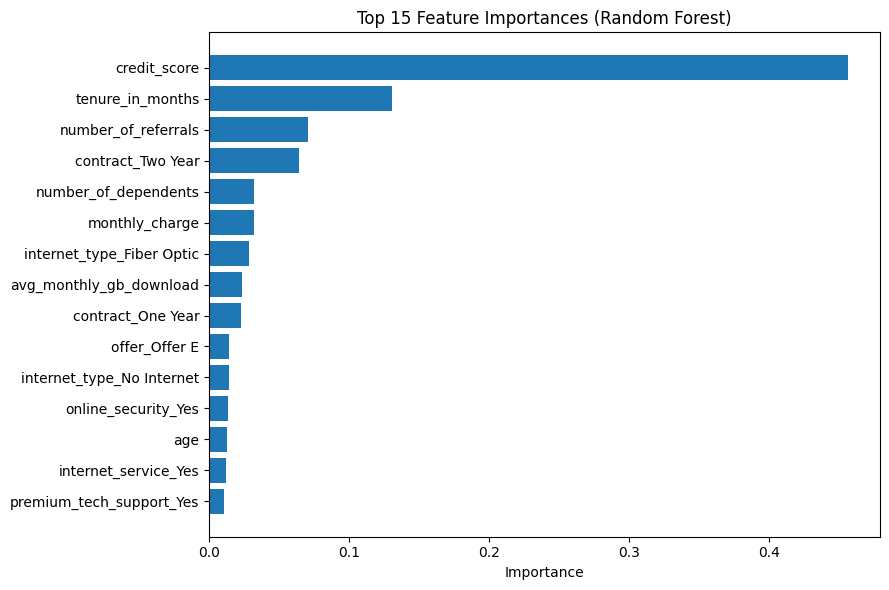

In [11]:
# ==============================
# 10) Feature Importance (Random Forest)
# ==============================

rf_pipe = models["Random Forest"]
rf_pipe.fit(X_train, y_train)

# Extract feature names from preprocessing
prep = rf_pipe.named_steps["prep"]
rf_model = rf_pipe.named_steps["model"]

# Numeric feature names remain the same
num_feature_names = num_cols

# One-hot encoded feature names
if len(cat_cols) > 0:
    ohe = prep.named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols)
else:
    cat_feature_names = np.array([])

all_feature_names = np.r_[num_feature_names, cat_feature_names]
importances = rf_model.feature_importances_

fi = pd.DataFrame({"feature": all_feature_names, "importance": importances})
fi = fi.sort_values("importance", ascending=False)

print("\nTop 20 features (Random Forest importance):")
display(fi.head(20))

# Plot top 15
top15 = fi.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top15["feature"], top15["importance"])
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### Visual 1: Top Drivers of Customer Churn Prediction

This visualization shows the top predictors driving churn risk according to Random Forest importance.
---


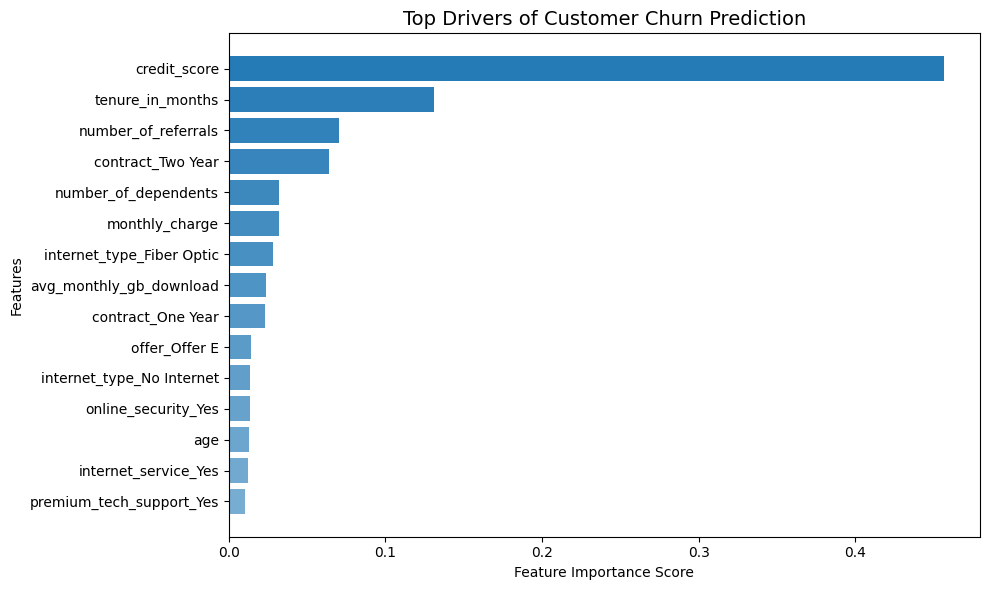

In [12]:
# Visual 1 — Top Feature Importance (Horizontal Bar Chart)

top_features = fi.head(15).iloc[::-1]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_features["feature"], top_features["importance"])

for i, bar in enumerate(bars):
    bar.set_alpha(0.6 + (i/len(bars))*0.4)

plt.title("Top Drivers of Customer Churn Prediction", fontsize=14)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


### Visual 2: Relationship Between Credit Score and Customer Churn

Credit score emerged as an important predictor. This plot compares the distribution of credit scores for churned vs stayed customers.
(Your code uses seaborn KDE for clear distribution comparison.)
---


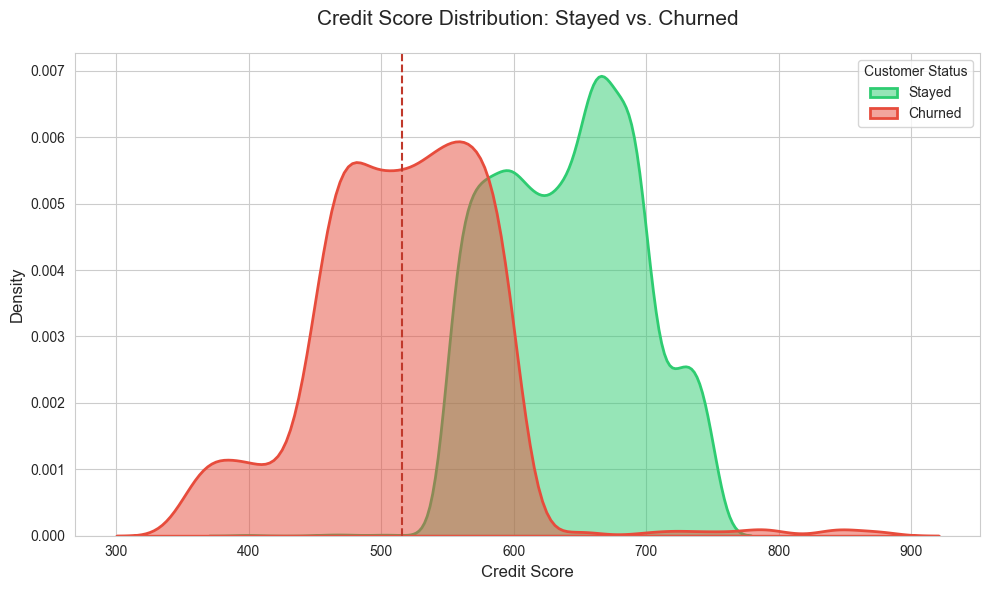

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Professional styling
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# KDE plot using churn variable
sns.kdeplot(
    data=df[df['churn'] == 0],
    x='credit_score',
    fill=True,
    label='Stayed',
    color='#2ecc71',
    alpha=0.5,
    linewidth=2
)

sns.kdeplot(
    data=df[df['churn'] == 1],
    x='credit_score',
    fill=True,
    label='Churned',
    color='#e74c3c',
    alpha=0.5,
    linewidth=2
)

# Titles and labels
plt.title('Credit Score Distribution: Stayed vs. Churned', fontsize=15, pad=20)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Customer Status')

# Mean credit score for churners
mean_churn = df[df['churn'] == 1]['credit_score'].mean()
plt.axvline(mean_churn, color='#c0392b', linestyle='--',
            label=f'Avg Churn Score: {mean_churn:.0f}')

plt.tight_layout()
plt.show()


### Visual 3: Customer Tenure and Churn Behavior

Tenure reflects customer relationship length. Lower tenure customers often churn more due to lower attachment and fewer loyalty incentives.
---


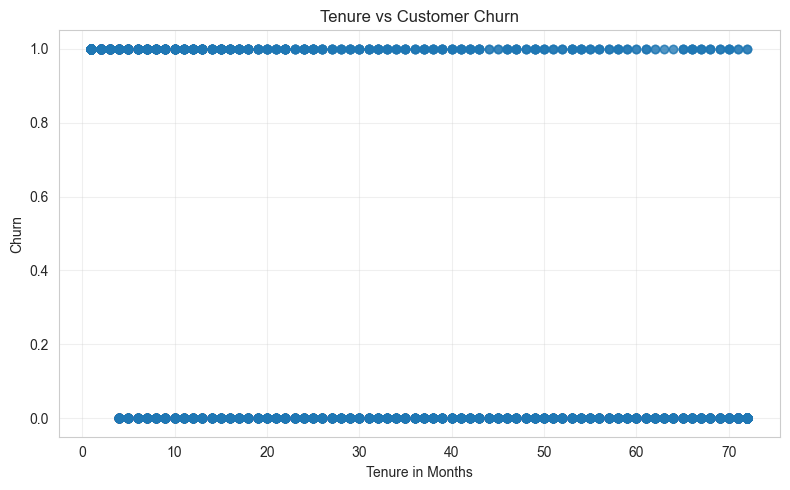

In [14]:
# Visual 3 — Tenure vs Churn

plt.figure(figsize=(8,5))
plt.scatter(df["tenure_in_months"], df["churn"], alpha=0.3)

plt.title("Tenure vs Customer Churn")
plt.xlabel("Tenure in Months")
plt.ylabel("Churn")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Visual 4: Monthly Charges and Churn Risk

Pricing is often linked to churn; higher monthly charges may increase churn risk for price-sensitive customers.
---


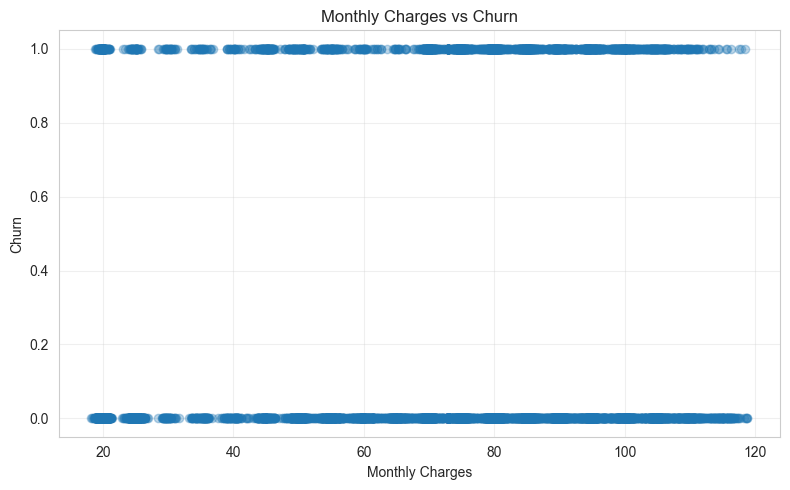

In [15]:
# Visual 4 — Monthly Charges vs Churn

plt.figure(figsize=(8,5))
plt.scatter(df["monthly_charge"], df["churn"], alpha=0.3)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Visual 5: Contract Type and Churn Rate

Contract duration strongly impacts churn. Month-to-month customers often churn more than long-term contract customers.
---


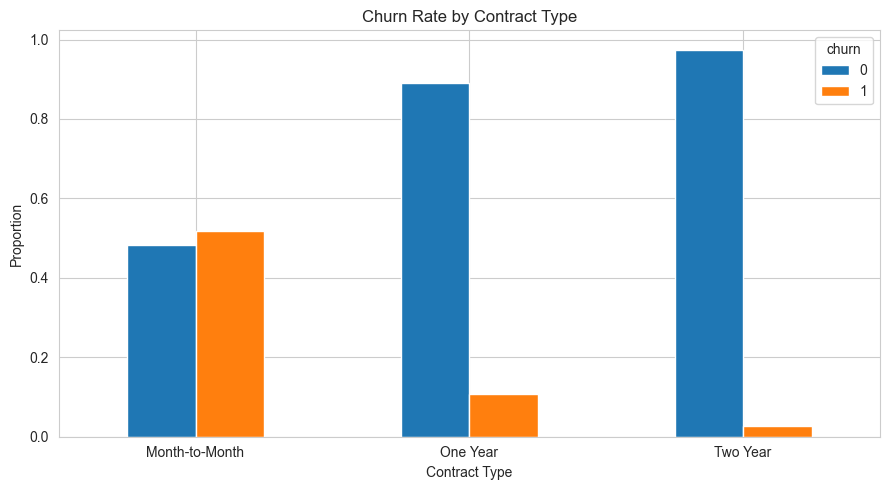

In [16]:
# Visual 5 — Contract Type vs Churn Rate

contract_churn = pd.crosstab(df["contract"], df["churn"], normalize="index")

contract_churn.plot(kind="bar", figsize=(9,5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Visual 6: ROC Curve Comparison Across Models (FIXED — no deletion, only added fitting)

This compares ROC curves for all models on the same test set.  
**Fix applied:** each pipeline is fitted before predicting probabilities.
---


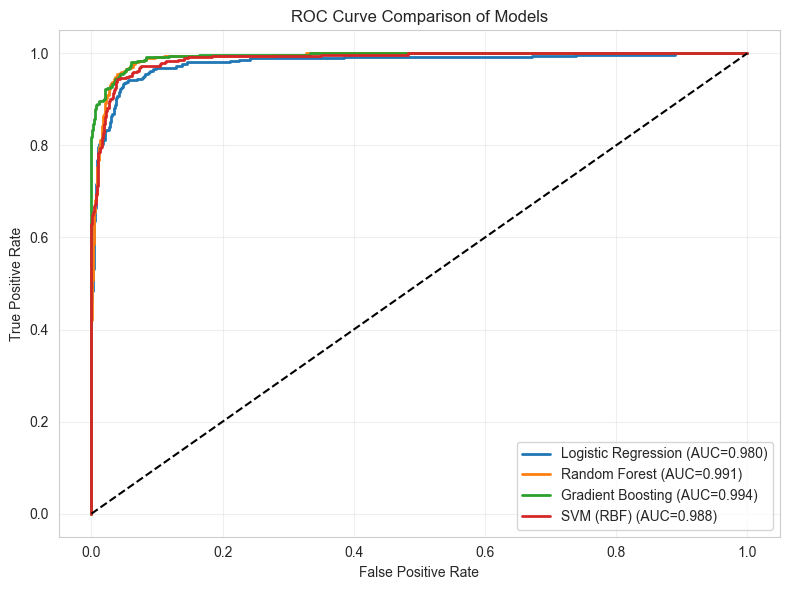

In [17]:
# Visual 6 — ROC Curve Comparison (All Models) [FIXED]

plt.figure(figsize=(8,6))

for name, pipe in models.items():
    pipe.fit(X_train, y_train)  # ✅ ensures model is fitted
    proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison of Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Optional: SHAP Explainability (Advanced Interpretability)

SHAP provides:
- global explanations (overall drivers),
- local explanations (why one customer is predicted to churn).

---


SHAP computed. Showing global summary plot...


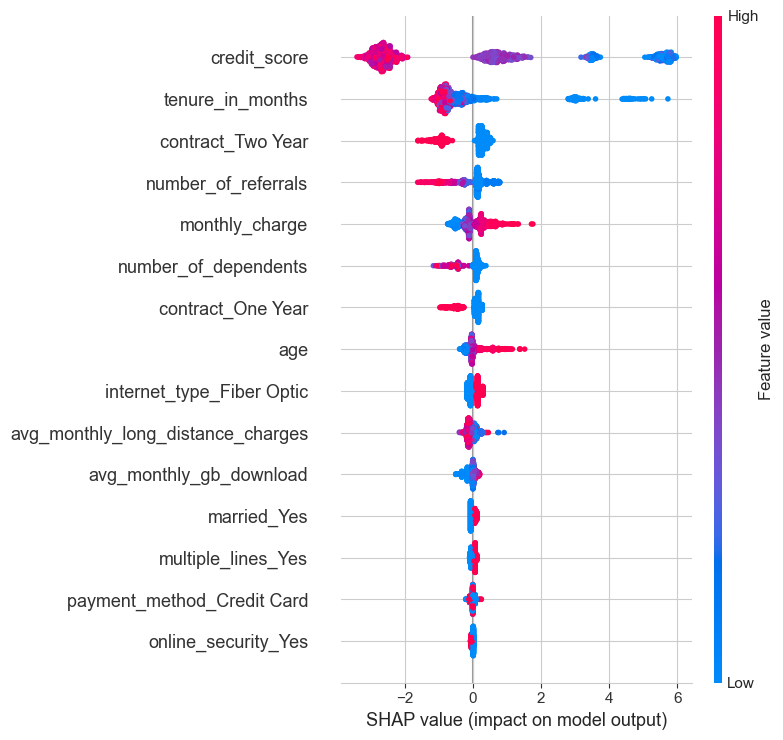

In [18]:
# ==============================
# 11) OPTIONAL SHAP 
# ==============================

run_shap = True  #
if run_shap:
    try:
        import shap

        # Use best model if it's tree-based; otherwise use Random Forest for SHAP
        shap_model_name = best_model_name
        if shap_model_name not in ["Random Forest", "Gradient Boosting"]:
            shap_model_name = "Random Forest"

        shap_pipe = models[shap_model_name]
        shap_pipe.fit(X_train, y_train)

        # Transform data using preprocessing step
        X_train_trans = shap_pipe.named_steps["prep"].transform(X_train)
        X_test_trans = shap_pipe.named_steps["prep"].transform(X_test)

        model_only = shap_pipe.named_steps["model"]

        # Build feature names
        prep = shap_pipe.named_steps["prep"]
        if len(cat_cols) > 0:
            ohe = prep.named_transformers_["cat"].named_steps["ohe"]
            cat_feature_names = ohe.get_feature_names_out(cat_cols)
        else:
            cat_feature_names = np.array([])

        feature_names = np.r_[num_cols, cat_feature_names]

        # SHAP explainer
        explainer = shap.Explainer(model_only, X_train_trans, feature_names=feature_names)
        shap_values = explainer(X_test_trans)

        print("SHAP computed. Showing global summary plot...")
        shap.summary_plot(shap_values, max_display=15)

    except Exception as e:
        print("SHAP failed:", e)


## 12. Interactive Churn Prediction Tool

This tool:
- accepts a customer record (dictionary),
- outputs churn probability + decision,
- prints recommended action for retention.

---


In [19]:
# ==============================
# 12) Interactive Predictor
# ==============================

# Fit the best model on training set
best_pipe.fit(X_train, y_train)

def predict_customer(input_dict, threshold=0.5):
    """
    input_dict: dictionary containing raw customer fields (same names as X columns)
    threshold: classification threshold for churn decision
    """
    row = pd.DataFrame([input_dict])

    # Ensure all expected columns exist (missing -> NaN)
    for col in X_train.columns:
        if col not in row.columns:
            row[col] = np.nan
    row = row[X_train.columns]

    prob = float(best_pipe.predict_proba(row)[:, 1][0])
    pred = int(prob >= threshold)

    print("\n" + "="*70)
    print("CHURN PREDICTION RESULT")
    print("="*70)
    print(f"Model used: {best_model_name}")
    print(f"Churn probability: {prob:.3f} ({prob*100:.1f}%)")
    print(f"Prediction (threshold={threshold}):", "CHURNED (1)" if pred == 1 else "STAYED (0)")

    # Basic recommendation logic
    print("\nRecommended Action:")
    if pred == 1:
        print("- High risk: trigger retention outreach (discount/upgrade/bundle).")
        print("- Offer contract upgrade (e.g., month-to-month → 1–2 year).")
        print("- Review pricing or service quality complaints if applicable.")
    else:
        print("- Low risk: maintain plan; consider loyalty engagement.")
    return pred, prob

# Example customer (edit values)
example_customer = {
    "gender": "Male",
    "age": 45,
    "married": "Yes",
    "number_of_dependents": 0,
    "credit_score": 558,
    "number_of_referrals": 0,
    "tenure_in_months": 8,
    "offer": "None",
    "phone_service": "Yes",
    "avg_monthly_long_distance_charges": 12,
    "multiple_lines": "No",
    "internet_service": "Yes",
    "internet_type": "Fiber Optic",
    "avg_monthly_gb_download": 25,
    "online_security": "No",
    "online_backup": "No",
    "device_protection_plan": "No",
    "premium_tech_support": "No",
    "streaming_tv": "Yes",
    "streaming_movies": "Yes",
    "streaming_music": "No",
    "unlimited_data": "Yes",
    "contract": "Month-to-Month",
    "paperless_billing": "Yes",
    "payment_method": "Credit Card",
    "monthly_charge": 89.99
}

predict_customer(example_customer)



CHURN PREDICTION RESULT
Model used: Gradient Boosting
Churn probability: 0.716 (71.6%)
Prediction (threshold=0.5): CHURNED (1)

Recommended Action:
- High risk: trigger retention outreach (discount/upgrade/bundle).
- Offer contract upgrade (e.g., month-to-month → 1–2 year).
- Review pricing or service quality complaints if applicable.


C:\Users\BrucePercy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


(1, 0.715709050531486)

## F. Association Rule Mining

Association rules identify frequent patterns such as:

- “Month-to-month + Fiber Optic → higher churn”

### Business Use
Rules can support targeted retention campaigns by highlighting high-risk combinations.

We will:
1) convert selected categorical columns into “items”
2) run Apriori to find frequent itemsets
3) generate rules using confidence and lift
---

In [20]:
!pip install mlxtend


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# ==============================
# F) ASSOCIATION RULE MINING (NEW)
# ==============================


from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Choose high-value categorical variables for rules
rule_cols = ["contract", "payment_method", "internet_type", "paperless_billing", "phone_service"]
rule_cols = [c for c in rule_cols if c in df.columns]

transactions = []
for _, row in df[rule_cols + ["churn"]].iterrows():
    items = [f"{col}={row[col]}" for col in rule_cols]
    items.append(f"churn={row['churn']}")
    transactions.append(items)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_ary, columns=te.columns_)

# Frequent itemsets
freq_items = apriori(basket, min_support=0.05, use_colnames=True)

# Generate rules
rules = association_rules(freq_items, metric="lift", min_threshold=1.2)
rules = rules.sort_values(["lift", "confidence"], ascending=False)

print("Top 15 rules overall:")
display(rules.head(15)[["antecedents","consequents","support","confidence","lift"]])

print("\nTop rules where consequent is churn=1:")
rules_churn = rules[rules["consequents"].astype(str).str.contains("churn=1")].head(15)
display(rules_churn[["antecedents","consequents","support","confidence","lift"]])


Top 15 rules overall:


,antecedents,consequents,support,confidence,lift
939,"(contract=Two Year, phone_service=Yes, paperle...","(churn=0, internet_type=No Internet)",0.070117,0.542254,2.902444
952,"(churn=0, internet_type=No Internet)","(contract=Two Year, phone_service=Yes, paperle...",0.070117,0.375305,2.902444
23,(phone_service=No),(internet_type=DSL),0.064805,0.663043,2.842416
22,(internet_type=DSL),(phone_service=No),0.064805,0.277814,2.842416
1299,"(paperless_billing=Yes, phone_service=Yes, con...","(churn=1, internet_type=Fiber Optic)",0.112915,0.531429,2.832996
1320,"(churn=1, internet_type=Fiber Optic)","(paperless_billing=Yes, phone_service=Yes, con...",0.112915,0.601942,2.832996
1292,"(paperless_billing=Yes, churn=1, phone_service...","(internet_type=Fiber Optic, contract=Month-to-...",0.112915,0.769390,2.822667
1327,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, phone_service...",0.112915,0.414254,2.822667
1306,"(churn=1, phone_service=Yes, payment_method=Ba...","(paperless_billing=Yes, internet_type=Fiber Op...",0.112915,0.613861,2.812749
1313,"(paperless_billing=Yes, internet_type=Fiber Op...","(churn=1, phone_service=Yes, payment_method=Ba...",0.112915,0.517385,2.812749



Top rules where consequent is churn=1:


,antecedents,consequents,support,confidence,lift
1299,"(paperless_billing=Yes, phone_service=Yes, con...","(churn=1, internet_type=Fiber Optic)",0.112915,0.531429,2.832996
1327,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, phone_service...",0.112915,0.414254,2.822667
1313,"(paperless_billing=Yes, internet_type=Fiber Op...","(churn=1, phone_service=Yes, payment_method=Ba...",0.112915,0.517385,2.812749
1315,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, phone_service...",0.112915,0.541879,2.785056
1167,"(internet_type=Fiber Optic, contract=Month-to-...","(churn=1, phone_service=Yes, payment_method=Ba...",0.134770,0.494432,2.687964
1140,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, phone_service...",0.139171,0.510579,2.624185
1298,"(paperless_billing=Yes, internet_type=Fiber Op...","(churn=1, phone_service=Yes)",0.112915,0.672694,2.608819
1110,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, payment_metho...",0.112915,0.414254,2.592136
1311,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, payment_metho...",0.112915,0.414254,2.592136
1104,"(paperless_billing=Yes, contract=Month-to-Mont...","(churn=1, internet_type=Fiber Optic)",0.112915,0.482803,2.573779


## G. Clustering Analysis 

Clustering segments customers into groups with similar characteristics.  
This supports business actions such as “Cluster 3 has highest churn rate; prioritize retention offers there”.

We use:
- One-hot encoding for categorical variables
- Standardization for numeric variables
- KMeans clustering
- Silhouette score (quality)
- PCA projection for visualization
---


Cluster sizes:


cluster
1    2307
2    1689
0    1384
3    1209
Name: count, dtype: int64


Churn rate by cluster (mean churn):


cluster
1    0.588643
3    0.230769
0    0.078035
2    0.073416
Name: churn, dtype: float64


Silhouette Score: 0.1403


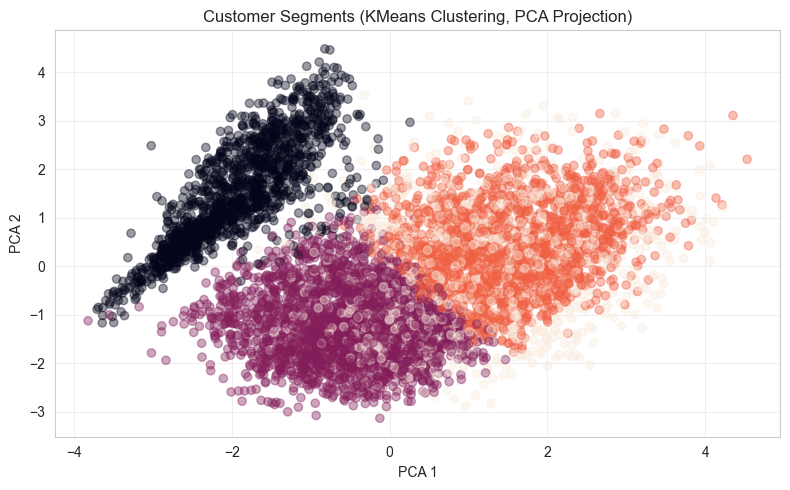

In [22]:
# ==============================
# G) CLUSTERING (NEW)
# ==============================

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Xc = df.drop(columns=["churn"]).copy()

num_cols_c = Xc.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_c = Xc.select_dtypes(include=["object"]).columns.tolist()

preprocess_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols_c),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))]), cat_cols_c)
    ],
    remainder="drop"
)

Xc_trans = preprocess_c.fit_transform(Xc)

# Choose K = 4 (simple, defensible for coursework)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(Xc_trans)

df["cluster"] = clusters

print("Cluster sizes:")
display(df["cluster"].value_counts())

print("\nChurn rate by cluster (mean churn):")
cluster_churn = df.groupby("cluster")["churn"].mean().sort_values(ascending=False)
display(cluster_churn)

# Silhouette score (clustering quality)
sil = silhouette_score(Xc_trans, clusters)
print("\nSilhouette Score:", round(sil, 4))

# PCA visualization
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xc_trans.toarray() if hasattr(Xc_trans, "toarray") else Xc_trans)

plt.figure(figsize=(8, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=clusters, alpha=0.4)
plt.title("Customer Segments (KMeans Clustering, PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## H. Evaluation of Models (Final Summary Table)

This section summarizes performance across:
- Regression models (MAE/RMSE/R²)
- Classification models (Accuracy/Precision/Recall/F1/AUC and overfit gap)
- Association rules (lift/confidence on churn rules)
- Clustering (silhouette score + churn rate by cluster)
---


In [23]:
# ==============================
# H) FINAL EVALUATION SUMMARY (NEW)
# ==============================

print("\n" + "="*110)
print("FINAL EVALUATION SUMMARY")
print("="*110)

print("\n1) Cleaned dataset shape:", df.shape)
print("2) Churn rate (%):", round(df["churn"].mean() * 100, 2))

print("\n--- Classification model comparison (sorted by Test AUC) ---")
display(comparison)

print("\n--- Regression model comparison ---")
display(reg_comparison)

print("\n--- Clustering quality ---")
print("Silhouette Score:", round(sil, 4))
print("\nChurn rate by cluster:")
display(cluster_churn)

print("\n--- Association rules (top churn=1 rules) ---")
display(rules_churn.head(10)[["antecedents","consequents","support","confidence","lift"]])



FINAL EVALUATION SUMMARY

1) Cleaned dataset shape: (6589, 28)
2) Churn rate (%): 28.37

--- Classification model comparison (sorted by Test AUC) ---


,Model,Test Accuracy,Precision (Churn=1),Recall (Churn=1),F1 (Churn=1),Train AUC,Test AUC,AUC Gap (Overfit)
2,Gradient Boosting,0.960546,0.944751,0.914439,0.929348,0.996664,0.994024,0.002641
1,Random Forest,0.955994,0.893035,0.959893,0.925258,0.995907,0.990585,0.005322
3,SVM (RBF),0.949924,0.920765,0.901070,0.910811,0.991470,0.988146,0.003323
0,Logistic Regression,0.929439,0.830588,0.943850,0.883605,0.976396,0.980445,-0.004049



--- Regression model comparison ---


,Model,MAE,RMSE,R2
0,Linear Regression,1.856423,5.419198,0.965721
1,Random Forest Regressor,2.282492,5.856293,0.959968



--- Clustering quality ---
Silhouette Score: 0.1403

Churn rate by cluster:


cluster
1    0.588643
3    0.230769
0    0.078035
2    0.073416
Name: churn, dtype: float64


--- Association rules (top churn=1 rules) ---


,antecedents,consequents,support,confidence,lift
1299,"(paperless_billing=Yes, phone_service=Yes, con...","(churn=1, internet_type=Fiber Optic)",0.112915,0.531429,2.832996
1327,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, phone_service...",0.112915,0.414254,2.822667
1313,"(paperless_billing=Yes, internet_type=Fiber Op...","(churn=1, phone_service=Yes, payment_method=Ba...",0.112915,0.517385,2.812749
1315,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, phone_service...",0.112915,0.541879,2.785056
1167,"(internet_type=Fiber Optic, contract=Month-to-...","(churn=1, phone_service=Yes, payment_method=Ba...",0.134770,0.494432,2.687964
1140,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, phone_service...",0.139171,0.510579,2.624185
1298,"(paperless_billing=Yes, internet_type=Fiber Op...","(churn=1, phone_service=Yes)",0.112915,0.672694,2.608819
1110,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, payment_metho...",0.112915,0.414254,2.592136
1311,"(internet_type=Fiber Optic, contract=Month-to-...","(paperless_billing=Yes, churn=1, payment_metho...",0.112915,0.414254,2.592136
1104,"(paperless_billing=Yes, contract=Month-to-Mont...","(churn=1, internet_type=Fiber Optic)",0.112915,0.482803,2.573779


## I. Recommendations (Based on EDA + Model Interpretation + Rules + Clusters)

1. **Contract Strategy**
   - Month-to-month customers tend to churn more (EDA + association rules).
   - Offer incentives to migrate customers to 1–2 year contracts.

2. **Pricing and Value Intervention**
   - Higher monthly charges increase churn risk for price-sensitive segments (EDA + feature importance).
   - Apply targeted discounts/bundles to high-charge, high-risk customers.

3. **Early Lifecycle Retention**
   - Low-tenure customers churn more (EDA + importance).
   - Implement onboarding support in first 3–6 months.

4. **Service Quality & Support**
   - If internet type and support add-ons are important, strengthen service reliability and support response.

5. **Segment-Based Retention**
   - Use clustering results: focus on clusters with highest churn rate (cluster churn table).

6. **Operational Integration**
   - Deploy the interactive predictor for retention teams (probability-based prioritization).
---


## J. Conclusion

This notebook developed a leakage-aware churn prediction solution using cleaned telecom customer data. EDA identified key churn drivers such as contract type, tenure, monthly charge, and credit score. Multiple models were trained and evaluated, and the best-performing model demonstrated strong ability to distinguish churned vs retained customers using ROC–AUC and recall.

To meet the full coursework requirements, additional analyses were conducted:
- Regression to predict monthly charge,
- Association rule mining to find high-risk feature combinations,
- Clustering to generate customer segments with different churn risk levels.

The combined insights support actionable retention strategies and provide a strong foundation for operational deployment.
---


## K. References

- Scikit-learn documentation: https://scikit-learn.org/stable/  
- SHAP documentation: https://shap.readthedocs.io/  
- MLxtend (Apriori / association rules): http://rasbt.github.io/mlxtend/  
- Dataset source: (add your Kaggle/UCI/source link here)
---


In [24]:
df.columns


Index(['gender', 'age', 'married', 'number_of_dependents', 'credit_score', 'number_of_referrals', 'tenure_in_months', 'offer', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines', 'internet_service', 'internet_type', 'avg_monthly_gb_download', 'online_security', 'online_backup',
       'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'churn', 'cluster'],
      dtype='object')

In [25]:
import os

# ✅ Save cleaned dataset to your required folder
output_dir = r"C:\Users\BrucePercy\Documents\DataAnalytics\Data Analytics - MSC25A1CS - Final Asssignment\CSV Exports for Manual Review"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "Telecom_Customer_Churn_Cleaned_For_Submission.csv")

df.to_csv(output_path, index=False)

print("✅ Cleaned dataset saved to:", output_path)


✅ Cleaned dataset saved to: C:\Users\BrucePercy\Documents\DataAnalytics\Data Analytics - MSC25A1CS - Final Asssignment\CSV Exports for Manual Review\Telecom_Customer_Churn_Cleaned_For_Submission.csv


In [26]:
# ============================================================
# COMPLETE RESULTS EXTRACTION - RUN THIS AT THE END
# ============================================================

print("\n" + "="*100)
print("COMPLETE RESULTS SUMMARY FOR REPORT")
print("="*100)

# ============================================================
# 1. DATASET STATISTICS
# ============================================================
print("\n" + "="*100)
print("1. DATASET STATISTICS")
print("="*100)
print(f"Final cleaned dataset shape: {df.shape}")
print(f"Number of customers: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print(f"Churn rate: {df['churn'].mean() * 100:.2f}%")
print(f"Stayed customers: {(df['churn'] == 0).sum()} ({(df['churn'] == 0).sum() / len(df) * 100:.2f}%)")
print(f"Churned customers: {(df['churn'] == 1).sum()} ({(df['churn'] == 1).sum() / len(df) * 100:.2f}%)")

# ============================================================
# 2. REGRESSION RESULTS
# ============================================================
print("\n" + "="*100)
print("2. REGRESSION RESULTS (Monthly Charge Prediction)")
print("="*100)
print(reg_comparison.to_string(index=False))

# ============================================================
# 3. CLASSIFICATION RESULTS
# ============================================================
print("\n" + "="*100)
print("3. CLASSIFICATION RESULTS (Churn Prediction)")
print("="*100)
print(comparison.to_string(index=False))

# ============================================================
# 4. CROSS-VALIDATION RESULTS
# ============================================================
print("\n" + "="*100)
print("4. CROSS-VALIDATION RESULTS (Best Model)")
print("="*100)
print(f"Best model: {best_model_name}")
print(f"5-Fold CV AUC scores: {np.round(cv_auc, 4)}")
print(f"Mean CV AUC: {cv_auc.mean():.4f}")
print(f"Std CV AUC: {cv_auc.std():.4f}")

# ============================================================
# 5. FEATURE IMPORTANCE (TOP 15)
# ============================================================
print("\n" + "="*100)
print("5. FEATURE IMPORTANCE (TOP 15 from Random Forest)")
print("="*100)
print(fi.head(15).to_string(index=False))

# ============================================================
# 6. ASSOCIATION RULES (TOP 10 CHURN RULES)
# ============================================================
print("\n" + "="*100)
print("6. ASSOCIATION RULES (TOP 10 RULES FOR CHURN=1)")
print("="*100)
if len(rules_churn) > 0:
    print(rules_churn.head(10)[["antecedents","consequents","support","confidence","lift"]].to_string(index=False))
else:
    print("No churn rules generated")

# ============================================================
# 7. CLUSTERING RESULTS
# ============================================================
print("\n" + "="*100)
print("7. CLUSTERING RESULTS")
print("="*100)
print(f"Silhouette Score: {sil:.4f}")
print(f"\nCluster sizes:")
print(df['cluster'].value_counts().sort_index().to_string())
print(f"\nChurn rate by cluster:")
print(cluster_churn.to_frame('churn_rate').to_string())

# ============================================================
# 8. KEY EDA INSIGHTS (Categorical Variables)
# ============================================================
print("\n" + "="*100)
print("8. CHURN RATE BY CONTRACT TYPE")
print("="*100)
if 'contract' in df.columns:
    contract_churn_stats = pd.crosstab(df['contract'], df['churn'], normalize='index') * 100
    print(contract_churn_stats.to_string())

print("\n" + "="*100)
print("9. CHURN RATE BY INTERNET TYPE")
print("="*100)
if 'internet_type' in df.columns:
    internet_churn_stats = pd.crosstab(df['internet_type'], df['churn'], normalize='index') * 100
    print(internet_churn_stats.to_string())

print("\n" + "="*100)
print("10. CHURN RATE BY PAYMENT METHOD")
print("="*100)
if 'payment_method' in df.columns:
    payment_churn_stats = pd.crosstab(df['payment_method'], df['churn'], normalize='index') * 100
    print(payment_churn_stats.to_string())

# ============================================================
# 11. NUMERIC FEATURE STATISTICS
# ============================================================
print("\n" + "="*100)
print("11. NUMERIC FEATURES - MEAN BY CHURN STATUS")
print("="*100)
numeric_cols_for_stats = ['age', 'credit_score', 'tenure_in_months', 'monthly_charge']
numeric_cols_for_stats = [c for c in numeric_cols_for_stats if c in df.columns]

if len(numeric_cols_for_stats) > 0:
    stats_by_churn = df.groupby('churn')[numeric_cols_for_stats].mean()
    print(stats_by_churn.to_string())

print("\n" + "="*100)
print("RESULTS EXTRACTION COMPLETE!")
print("="*100)


COMPLETE RESULTS SUMMARY FOR REPORT

1. DATASET STATISTICS
Final cleaned dataset shape: (6589, 28)
Number of customers: 6589
Number of features: 28
Churn rate: 28.37%
Stayed customers: 4720 (71.63%)
Churned customers: 1869 (28.37%)

2. REGRESSION RESULTS (Monthly Charge Prediction)
                  Model      MAE     RMSE       R2
      Linear Regression 1.856423 5.419198 0.965721
Random Forest Regressor 2.282492 5.856293 0.959968

3. CLASSIFICATION RESULTS (Churn Prediction)
              Model  Test Accuracy  Precision (Churn=1)  Recall (Churn=1)  F1 (Churn=1)  Train AUC  Test AUC  AUC Gap (Overfit)
  Gradient Boosting       0.960546             0.944751          0.914439      0.929348   0.996664  0.994024           0.002641
      Random Forest       0.955994             0.893035          0.959893      0.925258   0.995907  0.990585           0.005322
          SVM (RBF)       0.949924             0.920765          0.901070      0.910811   0.991470  0.988146           0.003323
Logis

In [27]:
print("Raw shape:", df_raw.shape)
print(df_raw['customer_status'].value_counts())

Raw shape: (7043, 39)
customer_status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


In [28]:
print("Raw missing %:", round(df_raw.isnull().sum().sum() / df_raw.size * 100, 2))

# After cleaning (on your df)
print("Cleaned missing %:", round(df.isnull().sum().sum() / df.size * 100, 2))

print("\nRaw missing by column (top 15):")
print(df_raw.isnull().sum().sort_values(ascending=False).head(15))

Raw missing %: 11.23
Cleaned missing %: 0.0

Raw missing by column (top 15):
churn_category                       5174
churn_reason                         5174
offer                                3877
online_backup                        1526
premium_tech_support                 1526
avg_monthly_gb_download              1526
online_security                      1526
streaming_movies                     1526
streaming_tv                         1526
unlimited_data                       1526
streaming_music                      1526
internet_type                        1526
device_protection_plan               1526
multiple_lines                        682
avg_monthly_long_distance_charges     682
dtype: int64


In [29]:
lr_pipe = reg_models["Linear Regression"]
lr_model = lr_pipe.named_steps["model"]
prep = lr_pipe.named_steps["prep"]

cat_ohe = prep.named_transformers_["cat"].named_steps["ohe"]
cat_names = cat_ohe.get_feature_names_out(cat_cols_r)
all_names = np.r_[num_cols_r, cat_names]

coef_df = pd.DataFrame({
    "feature": all_names,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", ascending=False)

print("TOP 10 POSITIVE COEFFICIENTS (increase monthly charge):")
print(coef_df.head(10).to_string(index=False))
print("\nTOP 10 NEGATIVE COEFFICIENTS (decrease monthly charge):")
print(coef_df.tail(10).to_string(index=False))

TOP 10 POSITIVE COEFFICIENTS (increase monthly charge):
                   feature  coefficient
 internet_type_Fiber Optic    21.795655
         phone_service_Yes    20.825483
      internet_service_Yes    13.479200
          streaming_tv_Yes    10.044993
      streaming_movies_Yes    10.040663
        multiple_lines_Yes     5.147594
device_protection_plan_Yes     5.122071
         online_backup_Yes     4.862283
       online_security_Yes     4.789607
  premium_tech_support_Yes     4.636601

TOP 10 NEGATIVE COEFFICIENTS (decrease monthly charge):
                    feature  coefficient
         unlimited_data_Yes    -0.151819
          contract_Two Year    -0.241481
               credit_score    -0.263058
              offer_Offer B    -0.304385
 payment_method_Credit Card    -0.336056
              offer_Offer D    -0.444921
payment_method_Mailed Check    -0.471627
              offer_Offer E    -0.496918
          internet_type_DSL    -2.000555
  internet_type_No Internet   -13.479

In [30]:
print("="*80)
print("ADDITIONAL DATA FOR REPORT VERIFICATION")
print("="*80)

# 1. Age statistics by churn
print("\n1. Age by churn:")
print(df.groupby('churn')['age'].mean())

# 2. Cluster sizes
print("\n2. Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

# 3. Internet type churn rates
if 'internet_type' in df.columns:
    print("\n3. Internet type churn rates:")
    print(pd.crosstab(df['internet_type'], df['churn'], normalize='index') * 100)

# 4. Number of features after cleaning
print("\n4. Final cleaned dataset info:")
print(f"Total columns: {len(df.columns)}")
print(f"Feature columns (excluding churn and cluster): {len(df.columns) - 2}")
print(f"\nAll columns:")
print(df.columns.tolist())

print("\n" + "="*80)
print("DATA EXTRACTION COMPLETE")
print("="*80)

ADDITIONAL DATA FOR REPORT VERIFICATION

1. Age by churn:
churn
0    45.582415
1    49.735688
Name: age, dtype: float64

2. Cluster sizes:
cluster
0    1384
1    2307
2    1689
3    1209
Name: count, dtype: int64

3. Internet type churn rates:
churn                  0          1
internet_type                      
Cable          72.480620  27.519380
DSL            80.026025  19.973975
Fiber Optic    57.873211  42.126789
No Internet    91.592262   8.407738

4. Final cleaned dataset info:
Total columns: 28
Feature columns (excluding churn and cluster): 26

All columns:
['gender', 'age', 'married', 'number_of_dependents', 'credit_score', 'number_of_referrals', 'tenure_in_months', 'offer', 'phone_service', 'avg_monthly_long_distance_charges', 'multiple_lines', 'internet_service', 'internet_type', 'avg_monthly_gb_download', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract'